In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/net/nwgc/vol1/nobackup/czaka/mitoscope/smaht/benchmark/ont/output/qc_summary.tsv", sep='\t')
df[['Donor', 'Tissue', 'Seq_Tech', 'Center']] = df['Sample'].str.split('-', expand=True)
df = df.sort_values(['Donor', 'Tissue'])
df

,Sample,Mito_Read_Count,Mito_Coverage,Nuclear_Coverage,Mean_Read_Length,Mean_Meth_Fraction,Fraction_Meth_Sites_GT1,Fraction_Meth_Sites_GT5,Fraction_Meth_Sites_GT10,Fraction_Meth_Sites_GT20,Donor,Tissue,Seq_Tech,Center
0,ST001-1A_LIVER-ont-nygc,41247,16250.77,80.87,6593.18,0.0030,0.0334,0.0023,0.0023,0.0012,ST001,1A_LIVER,ont,nygc
3,ST001-1A_LIVER-ont-uwsc,48938,19841.92,44.20,6802.95,0.0032,0.0460,0.0012,0.0012,0.0000,ST001,1A_LIVER,ont,uwsc
7,ST001-1A_LIVER-ont-bcm,54220,32778.45,78.40,10104.80,0.0044,0.0898,0.0035,0.0023,0.0012,ST001,1A_LIVER,ont,bcm
4,ST001-1D_LUNG-ont-bcm,2265,1479.81,87.54,10924.42,0.0043,0.1050,0.0023,0.0012,0.0000,ST001,1D_LUNG,ont,bcm
11,ST001-1D_LUNG-ont-nygc,3008,1303.19,60.62,7260.94,0.0049,0.1605,0.0069,0.0000,0.0000,ST001,1D_LUNG,ont,nygc
13,ST001-1D_LUNG-ont-uwsc,1713,867.53,27.58,8477.38,0.0027,0.0656,0.0000,0.0000,0.0000,ST001,1D_LUNG,ont,uwsc
1,ST002-1D_LUNG-ont-uwsc,6368,2967.01,39.32,7800.32,0.0026,0.0380,0.0000,0.0000,0.0000,ST002,1D_LUNG,ont,uwsc
6,ST002-1D_LUNG-ont-bcm,3216,2211.05,90.35,11491.03,0.0038,0.0759,0.0012,0.0000,0.0000,ST002,1D_LUNG,ont,bcm
17,ST002-1D_LUNG-ont-nygc,3973,1827.48,72.73,7700.40,0.0045,0.1243,0.0035,0.0000,0.0000,ST002,1D_LUNG,ont,nygc
5,ST002-1G_COLON-ont-nygc,6421,2445.05,69.81,6376.08,0.0025,0.0391,0.0000,0.0000,0.0000,ST002,1G_COLON,ont,nygc


In [3]:
#plt.figure(figsize=(10, 6))
# sns.boxplot(
#     data=df, 
#     x="Tissue", 
#     y="Read_Count", 
#     hue="Donor", 
#     showfliers=False, 
#     palette="Set2"
# )
sns.stripplot(
    data=df, 
    x="Tissue", 
    y="Read_Count", 
    hue="Donor", 
    dodge=True, 
    alpha=1, 
    size=8, 
    linewidth=1,
    marker="o"
)
plt.title("Read Counts by Tissue and Sequencing Center")
plt.ylabel("Total Reads")
plt.xlabel("Tissue")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()



ValueError: Could not interpret value `Read_Count` for `y`. An entry with this name does not appear in `data`.

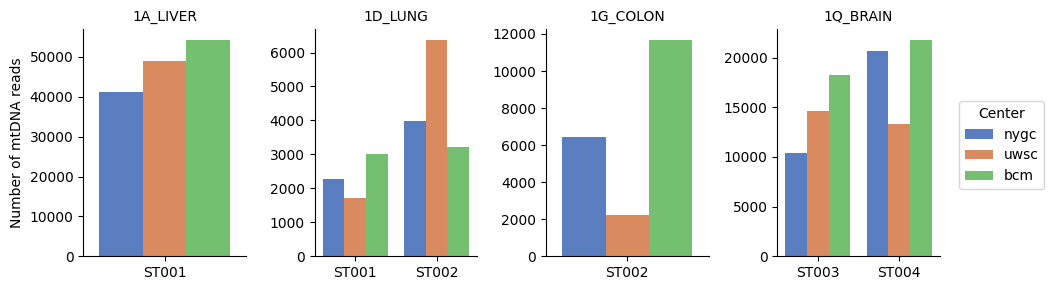

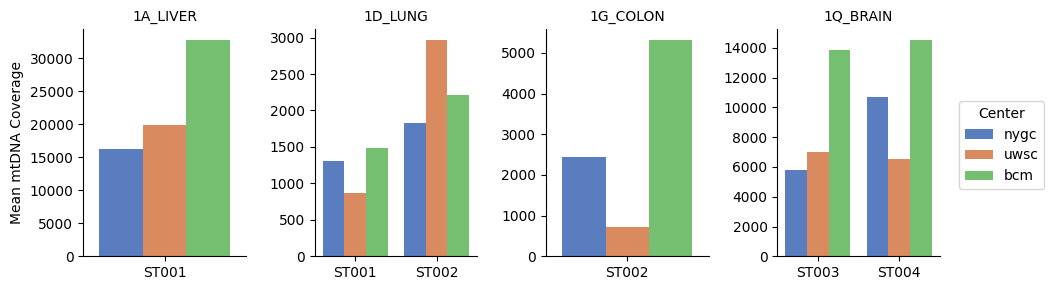

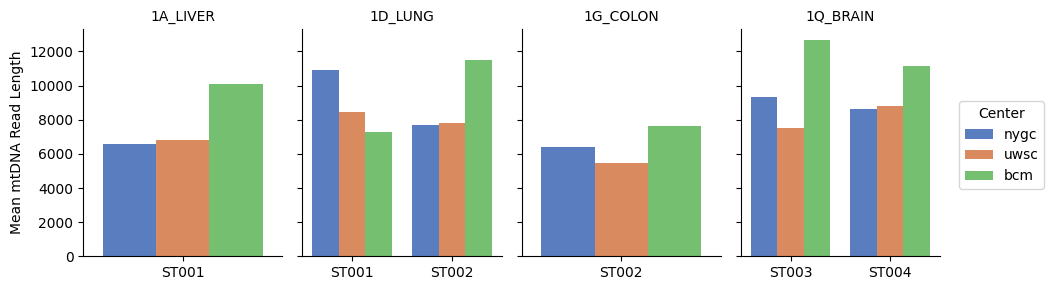

In [ ]:
g = sns.catplot(
    data=df,
    x="Donor",
    y="Read_Count",
    col="Tissue",
    hue="Center",
    kind="bar",
    height=3,
    aspect=0.8,
    palette="muted",
    legend_out=False,
    sharex=False,
    sharey=False
)
sns.move_legend(g, "center right", bbox_to_anchor=(1.1,0.5)) 
g.set_titles("{col_name}")
g.set_axis_labels("", "Number of mtDNA reads")
plt.tight_layout()
plt.show()

g = sns.catplot(
    data=df,
    x="Donor",
    y="Mean_Coverage",
    col="Tissue",
    hue="Center",
    kind="bar",
    height=3,
    aspect=0.8,
    palette="muted",
    legend_out=False,
    sharex=False,
    sharey=False
)
sns.move_legend(g, "center right", bbox_to_anchor=(1.1,0.5)) 
g.set_titles("{col_name}")
g.set_axis_labels("", "Mean mtDNA Coverage")
plt.tight_layout()
plt.show()

g = sns.catplot(
    data=df,
    x="Donor",
    y="Mean_Read_Length",
    col="Tissue",
    hue="Center",
    kind="bar",
    height=3,
    aspect=0.8,
    palette="muted",
    legend_out=False,
    sharex=False,
    sharey=True
)
sns.move_legend(g, "center right", bbox_to_anchor=(1.1,0.5)) 
g.set_titles("{col_name}")
g.set_axis_labels("", "Mean mtDNA Read Length")
plt.tight_layout()
plt.show()



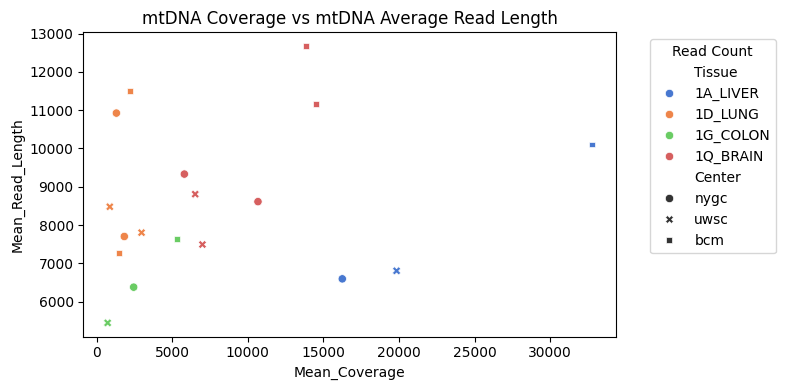

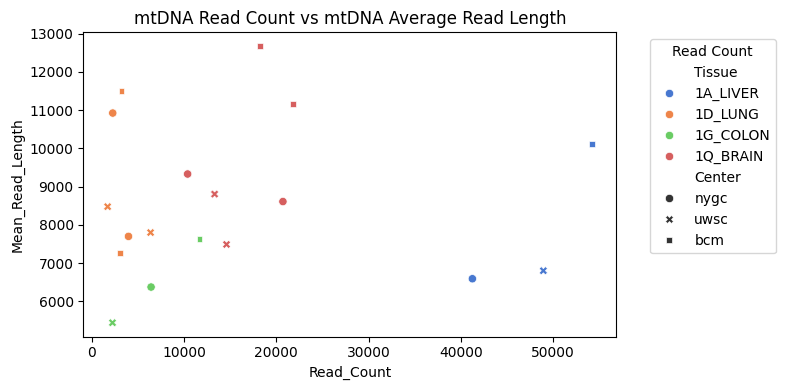

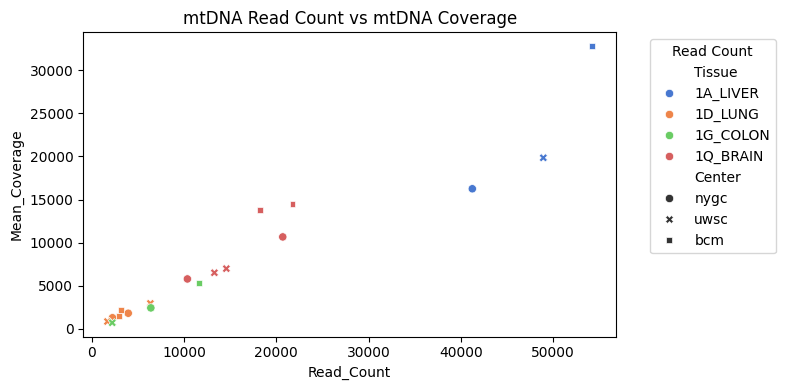

In [ ]:
plt.figure(figsize=(8,4))
sns.scatterplot(
    data=df,
    x="Mean_Coverage",
    y="Mean_Read_Length",
    hue="Tissue",       # color encodes read count
    palette="muted",
    style="Center",
 #   size="Read_Count",      # optional: also scale by size
 #   sizes=(40, 200),
    alpha=1
)
#plt.xscale('log')
plt.xlabel("Mean_Coverage")
plt.ylabel("Mean_Read_Length")
plt.title("mtDNA Coverage vs mtDNA Average Read Length")
plt.legend(title="Read Count", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


plt.figure(figsize=(8,4))
sns.scatterplot(
    data=df,
    x="Read_Count",
    y="Mean_Read_Length",
    hue="Tissue",       # color encodes read count
    palette="muted",
    style="Center",
  #  size="Read_Count",      # optional: also scale by size
  #  sizes=(40, 200),
    alpha=1
)
plt.xlabel("Read_Count")
plt.ylabel("Mean_Read_Length")
plt.title("mtDNA Read Count vs mtDNA Average Read Length")
plt.legend(title="Read Count", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


plt.figure(figsize=(8,4))
sns.scatterplot(
    data=df,
    x="Read_Count",
    y="Mean_Coverage",
    hue="Tissue",       # color encodes read count
    palette="muted",
    style="Center",
 #   size="Mean_Read_Length",      # optional: also scale by size
  #  sizes=(40, 200),
    alpha=1)
plt.xlabel("Read_Count")
plt.ylabel("Mean_Coverage")
plt.title("mtDNA Read Count vs mtDNA Coverage")
plt.legend(title="Read Count", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

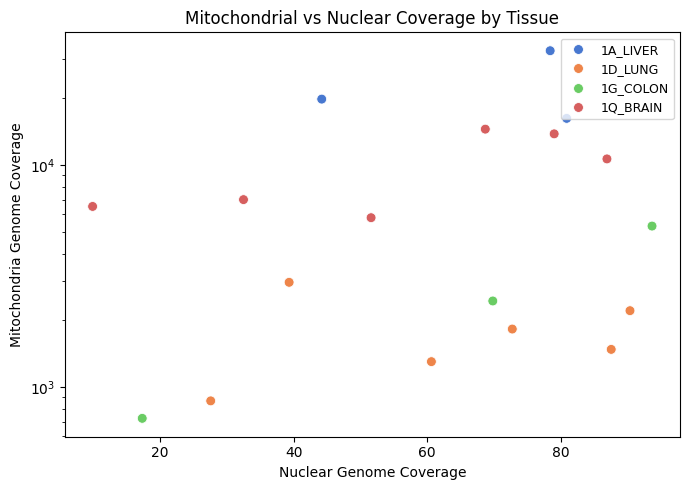

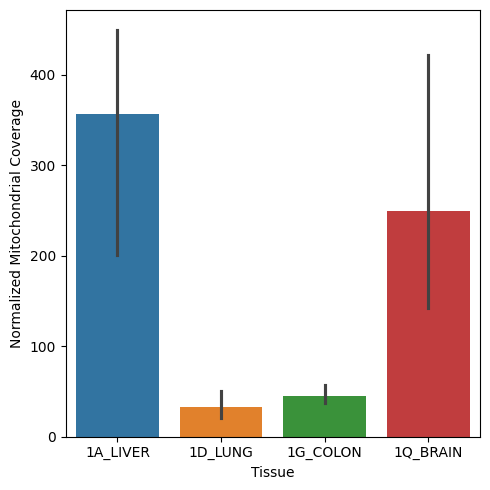

In [6]:
## mt coverage vs nuc coverage (pull from qc) - see tissue differences

plt.figure(figsize=(7,5))
sns.scatterplot(
    data=df,
    x="Nuclear_Coverage",
    y="Mito_Coverage",
    hue="Tissue",     
    palette="muted",
    s=50,
  #  style="Donor",
  # size="Nuclear_Coverage",      # optional: also scale by size
    sizes=(40, 200),
    alpha=1)
plt.xlabel("Nuclear Genome Coverage")
plt.ylabel("Mitochondria Genome Coverage")
plt.yscale("log")
#plt.xscale("log")
plt.title("Mitochondrial vs Nuclear Coverage by Tissue")
plt.legend(title="", loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()


df['mito_coverage_norm'] = df['Mito_Coverage'] / df['Nuclear_Coverage']
plt.figure(figsize=(5,5))
g = sns.barplot(
    data=df,
    x="Tissue",
    y="mito_coverage_norm",
    hue="Tissue",
)
plt.ylabel("Normalized Mitochondrial Coverage")
plt.tight_layout()
plt.show()





In [11]:
snv_vcf = pd.read_csv("/net/nwgc/vol1/nobackup/czaka/mitoscope/smaht/benchmark/ont/output/merged.baldur.annotated.txt",sep='\t')

snv_vcf['ID'] = snv_vcf[['CHROM', 'POS', 'REF', 'ALT']].astype(str).agg('-'.join, axis=1)

snv_vcf


,CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,FORMAT,ST001-1A_LIVER-ont-bcm,...,GB.Seqs.CR,Homoplasmy,Heteroplasmy,Disease,Status,References,Additional.Annotations,MitoTIP,Source,DiseaseVariantStatus
0,MT,64,MT-64-C-T,C,T,40,PASS,DP=30192,GT:ADF:ADR:HPL:FQSE:AQ:AFLT:QAVG:FSB:QBS,"././.:.:.:.:.:.:.,.:.:.:.",...,2050.0,NaN,NaN,NaN,NaN,46,MT-HV2,NaN,variant_df,General Variant
1,MT,64,MT-64-C-A,C,A,40,PASS,DP=10214,GT:ADF:ADR:HPL:FQSE:AQ:AFLT:QAVG:FSB:QBS,"././.:.:.:.:.:.:.,.:.:.:.",...,5.0,NaN,NaN,NaN,NaN,1,MT-HV2,NaN,variant_df,General Variant
2,MT,66,MT-66-G-del,G,del,40,PASS,DP=11323,GT:ADF:ADR:HPL:FQSE:AQ:AFLT:QAVG:FSB:QBS,"././.:.:.:.:.:.:.,.:.:.:.",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unknown Variant
3,MT,66,MT-66-G-A,G,A,40,PASS,DP=11323,GT:ADF:ADR:HPL:FQSE:AQ:AFLT:QAVG:FSB:QBS,"././.:.:.:.:.:.:.,.:.:.:.",...,70.0,NaN,NaN,NaN,NaN,5,MT-HV2,NaN,variant_df,General Variant
4,MT,72,MT-72-TA-del,TA,del,40,PASS,DP=4747,GT:ADF:ADR:HPL:FQSE:AQ:AFLT:QAVG:FSB:QBS,"./.:.:.:.:.:.:.,.:.:.:.",...,0.0,NaN,NaN,NaN,NaN,1,MT-HV2,NaN,variant_df,General Variant
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
136,MT,16304,MT-16304-T-C,T,C,40,PASS,DP=15128,GT:ADF:ADR:HPL:FQSE:AQ:AFLT:QAVG:FSB:QBS,"./.:.:.:.:.:.:.,.:.:.:.",...,8102.0,NaN,NaN,NaN,NaN,137,MT-HV1,NaN,variant_df,General Variant
137,MT,16311,MT-16311-T-C,T,C,40,PASS,DP=18653,GT:ADF:ADR:HPL:FQSE:AQ:AFLT:QAVG:FSB:QBS,"./.:.:.:.:.:.:.,.:.:.:.",...,14050.0,NaN,NaN,NaN,NaN,200,MT-HV1,NaN,variant_df,General Variant
138,MT,16375,MT-16375-C-del,C,del,40,PASS,DP=390,GT:ADF:ADR:HPL:FQSE:AQ:AFLT:QAVG:FSB:QBS,"./.:.:.:.:.:.:.,.:.:.:.",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unknown Variant
139,MT,16390,MT-16390-G-A,G,A,40,PASS,DP=24396,GT:ADF:ADR:HPL:FQSE:AQ:AFLT:QAVG:FSB:QBS,"./.:.:.:.:.:.:.,.:.:.:.",...,4686.0,+,-,POAG - potential for association,Reported,"3,86",NaN,NaN,"disease_df,variant_df",General Variant


In [12]:
filter_col = [col for col in snv_vcf if col.startswith('ST00')]

snv_df = pd.melt(
    snv_vcf[["POS", "ID"] + filter_col],
    id_vars=['POS', 'ID'],
    var_name='Sample',
    value_name='Value'
)

snv_df['Sample'] = snv_df['Sample'].str.removesuffix('.MT.filtered.bam')
snv_df[['Donor', 'Tissue', 'Seq_Tech', 'Center']] = snv_df['Sample'].str.split('-', expand=True)

snv_df


,POS,ID,Sample,Value,Donor,Tissue,Seq_Tech,Center
0,64,MT-64-C-T,ST001-1A_LIVER-ont-bcm,"././.:.:.:.:.:.:.,.:.:.:.",ST001,1A_LIVER,ont,bcm
1,64,MT-64-C-A,ST001-1A_LIVER-ont-bcm,"././.:.:.:.:.:.:.,.:.:.:.",ST001,1A_LIVER,ont,bcm
2,66,MT-66-G-del,ST001-1A_LIVER-ont-bcm,"././.:.:.:.:.:.:.,.:.:.:.",ST001,1A_LIVER,ont,bcm
3,66,MT-66-G-A,ST001-1A_LIVER-ont-bcm,"././.:.:.:.:.:.:.,.:.:.:.",ST001,1A_LIVER,ont,bcm
4,72,MT-72-TA-del,ST001-1A_LIVER-ont-bcm,"./.:.:.:.:.:.:.,.:.:.:.",ST001,1A_LIVER,ont,bcm
...,...,...,...,...,...,...,...,...
2533,16304,MT-16304-T-C,ST004-1Q_BRAIN-ont-uwsc,"./.:.:.:.:.:.:.,.:.:.:.",ST004,1Q_BRAIN,ont,uwsc
2534,16311,MT-16311-T-C,ST004-1Q_BRAIN-ont-uwsc,"./.:.:.:.:.:.:.,.:.:.:.",ST004,1Q_BRAIN,ont,uwsc
2535,16375,MT-16375-C-del,ST004-1Q_BRAIN-ont-uwsc,"./.:.:.:.:.:.:.,.:.:.:.",ST004,1Q_BRAIN,ont,uwsc
2536,16390,MT-16390-G-A,ST004-1Q_BRAIN-ont-uwsc,"./.:.:.:.:.:.:.,.:.:.:.",ST004,1Q_BRAIN,ont,uwsc


In [ ]:
snv_df[['GT', 'ADF', 'ADR','HPL', 'FQSE', 'AQ', 'AFLT', 'QAVG', 'FSB', 'QBS']] = snv_df['Value'].str.split(':', expand=True)
#snv_df[['GT', 'AF', 'BQ', 'DP']] = snv_df['Value'].str.split(':', expand=True)

#snv_df[['CHROM', 'POS', 'REF', 'ALT']] = snv_df['ID'].str.split('-', expand=True)
snv_df = snv_df.drop(columns=['Value'])
snv_df = snv_df[(snv_df['GT'] != '.') & (snv_df['GT'] != './.') & (snv_df['GT'] != '././.') & (snv_df['GT'] != './././.') & (snv_df['GT'] != '././././.')]
snv_df['AF'] = snv_df['HPL']


def extract_element(row):
    if ',' in row['AF']:
        parts = row['AF'].split(',')
        if row['GT'] == '0/1':
            return parts[1]
        elif row['GT'] == '1/0':
            return parts[0]
    return row['AF']

snv_df['AF'] = snv_df.apply(extract_element, axis=1)

snv_df.to_csv('look.csv')
#snv_df['AF'] = snv_df['AF'].astype(float)
#snv_df

In [11]:
# Count unique samples per variant
variant_sample_counts = snv_df.groupby('ID')['Sample'].nunique().reset_index()
variant_sample_counts.columns = ['ID', 'SampleCount']

# Count unique samples per variant
variant_tissue_counts = snv_df.groupby('ID')['Tissue'].nunique().reset_index()
variant_tissue_counts.columns = ['ID', 'TissueCount']

merged_counts = pd.merge(variant_sample_counts, variant_tissue_counts, on="ID")
merged_counts['POS'] = merged_counts['ID'].str.split('-').str[1].astype(int)
merged_counts = merged_counts.sort_values(['TissueCount', 'SampleCount'])

merged_counts

#can i add avg heteroplasmy levels?


,ID,SampleCount,TissueCount,POS
0,MT-10197-G-A,1,1,10197
1,MT-10197-G-C,1,1,10197
11,MT-12561-G-C,1,1,12561
14,MT-12736-G-A,1,1,12736
20,MT-13949-C-T,1,1,13949
...,...,...,...,...
84,MT-310-T-C,22,4,310
85,MT-310-T-TC,22,4,310
101,MT-4769-A-G,22,4,4769
134,MT-750-A-G,22,4,750


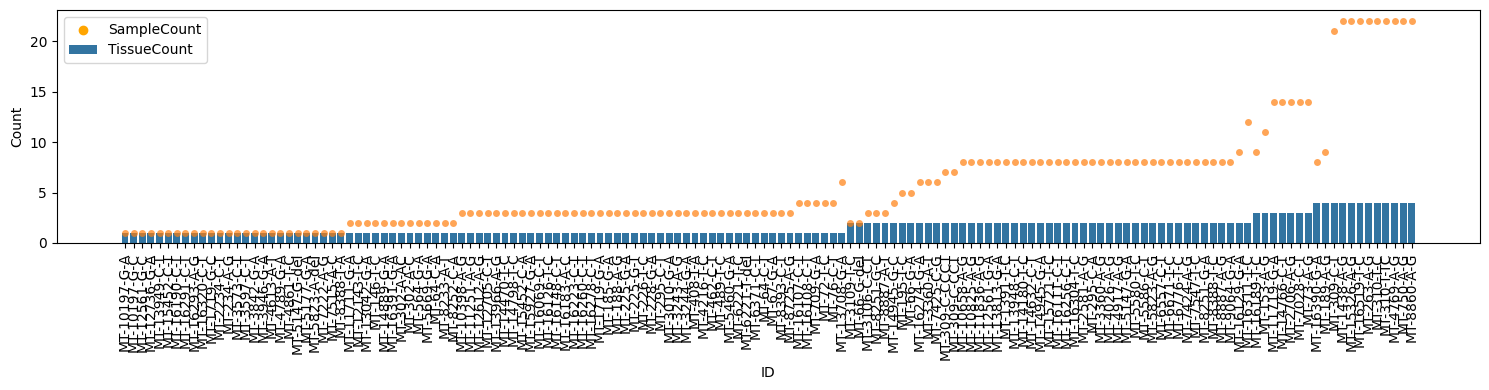

In [12]:
plt.figure(figsize=(15,4))
sns.barplot(data=merged_counts, y='TissueCount', x='ID', label='TissueCount')
sns.stripplot(data=merged_counts, x='ID', y='SampleCount', jitter=True, alpha=0.7)
plt.scatter([], [], color='orange', label='SampleCount')  # Empty but adds one legend entry
plt.xticks(rotation=90)
plt.tight_layout()
plt.ylabel('Count')
plt.legend()
plt.show()



In [13]:
# Filter variants with only one unique sample
singletons = merged_counts[merged_counts["TissueCount"] == 1]
singleton_df = snv_df[snv_df['ID'].isin(singletons['ID'])]
singleton_df


,POS,ID,Sample,Donor,Tissue,Seq_Tech,Center,Group,GT,ADF,ADR,HPL,FQSE,AQ,AFLT,QAVG,FSB,QBS,AF
4,67,MT-67-G-A,ST001-1A_LIVER-pacbio-bcm,ST001,1A_LIVER,pacbio,bcm,None,0/1,"2608,17","8821,36",0.00359,"0.0007,0.00064","40,40","PASS,PASS","29.76,29.85","1,0.138","1,0.318",0.00359
5,72,MT-72-T-C,ST001-1A_LIVER-pacbio-bcm,ST001,1A_LIVER,pacbio,bcm,None,0/1,"2519,107","8577,281",0.03239,"0.00171,0.00169","40,40","PASS,PASS","29.67,29.49","1,0.0268","1,1.35e-08",0.03239
7,76,MT-76-C-T,ST001-1A_LIVER-pacbio-bcm,ST001,1A_LIVER,pacbio,bcm,None,0/1,"2615,13","8812,54",0.00485,"0.00078,0.00072","40,40","PASS,PASS","29.4,29.96","1,0.562","1,0.619",0.00485
128,16107,MT-16107-C-T,ST001-1A_LIVER-pacbio-bcm,ST001,1A_LIVER,pacbio,bcm,None,0/1,"2694,25","9003,79",0.00776,"0.00092,0.00087","40,40","PASS,PASS","29.42,29.73","1,0.815","1,0.414",0.00776
129,16108,MT-16108-C-T,ST001-1A_LIVER-pacbio-bcm,ST001,1A_LIVER,pacbio,bcm,None,0/1,"2670,48","8928,168",0.01734,"0.0013,0.00127","40,40","PASS,PASS","28.68,29.74","1,0.807","1,0.266",0.01734
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3283,16148,MT-16148-C-T,ST004-1Q_BRAIN-pacbio-washu,ST004,1Q_BRAIN,pacbio,washu,None,0/1,"6974,56","21187,147",0.00607,"0.00055,0.00051","40,40","PASS,PASS","28.83,29.57","1,0.369","1,0.115",0.00607
3284,16183,MT-16183-A-C,ST004-1Q_BRAIN-pacbio-washu,ST004,1Q_BRAIN,pacbio,washu,None,0/1,"623,6306","1789,19263",0.91797,"0.00169,0.0017","40,40","PASS,PASS","27,28.37","0.208,1","0,1",0.91797
3287,16223,MT-16223-C-T,ST004-1Q_BRAIN-pacbio-washu,ST004,1Q_BRAIN,pacbio,washu,None,1,"1,7064","17,21310",1,"0,0.00019","0,40","qual_bias;q30;low_freq,PASS","24.5,29.7","0.0958,1","0,1",1.00000
3289,16260,MT-16260-C-T,ST004-1Q_BRAIN-pacbio-washu,ST004,1Q_BRAIN,pacbio,washu,None,0/1,"29,7036","50,21303",0.99886,"0.00028,0.00034","40,40","qual_bias;low_freq,PASS","25.96,29.72","0.0186,1","0,1",0.99886


In [14]:
## variants present in most tissues 
common_variants = merged_counts[merged_counts["TissueCount"] > 2]
common_variants_df = snv_df[snv_df['ID'].isin(common_variants['ID'])]
common_variants_df

,POS,ID,Sample,Donor,Tissue,Seq_Tech,Center,Group,GT,ADF,ADR,HPL,FQSE,AQ,AFLT,QAVG,FSB,QBS,AF
9,153,MT-153-A-G,ST001-1A_LIVER-pacbio-bcm,ST001,1A_LIVER,pacbio,bcm,None,0/1,"63,2576","180,8708",0.98001,"0.00134,0.00138","40,40","PASS,PASS","29.77,29.63","0.28,1","0.2,1",0.98001
12,189,MT-189-A-G,ST001-1A_LIVER-pacbio-bcm,ST001,1A_LIVER,pacbio,bcm,None,0/1,"2651,11","8901,33",0.00268,"0.00065,0.00058","40,40","PASS,PASS","29.27,29.5","1,0.858","1,0.0273",0.00268
19,263,MT-263-A-G,ST001-1A_LIVER-pacbio-bcm,ST001,1A_LIVER,pacbio,bcm,None,1,"0,2667","0,8940",1,"0,0.0003","0,40","q30;low_freq,PASS","0,29.68","1,1","1,1",1.00000
24,309,MT-309-C-T,ST001-1A_LIVER-pacbio-bcm,ST001,1A_LIVER,pacbio,bcm,None,0/1,"2388,205","8056,639",0.0803,"0.00302,0.00289","40,40","PASS,PASS","21.28,28.73","1,0.349","1,0.000279",0.08030
27,310,MT-310-T-C,ST001-1A_LIVER-pacbio-bcm,ST001,1A_LIVER,pacbio,bcm,None,0/0/1,"150,273","580,877",0.09384,"0.00252,0.00295","40,40","PASS,PASS","28.79,26.23","0.143,0.578","4.9e-05,0",0.09384
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3267,14766,MT-14766-C-T,ST004-1Q_BRAIN-pacbio-washu,ST004,1Q_BRAIN,pacbio,washu,None,1,"0,7020","0,21238",1,"0,0.00019","0,40","q30;low_freq,PASS","0,29.64","1,1","1,1",1.00000
3272,15326,MT-15326-A-G,ST004-1Q_BRAIN-pacbio-washu,ST004,1Q_BRAIN,pacbio,washu,None,1,"0,7016","4,21283",1,"0,0.00019","0,40","qual_bias;q30;low_freq,PASS","13.25,29.52","0.578,1","9.77e-12,1",1.00000
3285,16189,MT-16189-T-C,ST004-1Q_BRAIN-pacbio-washu,ST004,1Q_BRAIN,pacbio,washu,None,1,"5,7033","7,21308",1,"0,0.00019","0,40","q30;low_freq,PASS","28.33,29.79","0.187,1","0.0391,1",1.00000
3297,16390,MT-16390-G-A,ST004-1Q_BRAIN-pacbio-washu,ST004,1Q_BRAIN,pacbio,washu,None,0/1,"7013,32","21180,83",0.00298,"0.00042,0.00038","40,40","PASS,PASS","29.9,29.65","1,0.517","1,3.06e-06",0.00298


In [15]:
# Filter variants in multiple tissues but not all?
other_variants = merged_counts[(merged_counts["TissueCount"] > 1) & (merged_counts["TissueCount"] < 3)]
other_variants_df = snv_df[snv_df['ID'].isin(other_variants['ID'])]
other_variants_df

,POS,ID,Sample,Donor,Tissue,Seq_Tech,Center,Group,GT,ADF,ADR,HPL,FQSE,AQ,AFLT,QAVG,FSB,QBS,AF
3,66,MT-66-G-A,ST001-1A_LIVER-pacbio-bcm,ST001,1A_LIVER,pacbio,bcm,None,0/1,"2492,17","8548,46",0.00472,"0.00161,0.00075","40,40","PASS,PASS","27.62,29.68","1,0.449","1,0.754",0.00472
40,2581,MT-2581-A-G,ST001-1A_LIVER-pacbio-bcm,ST001,1A_LIVER,pacbio,bcm,None,1,"3,2641","6,8868",1,"0,0.0003","0,40","q30;low_freq,PASS","29.11,29.44","0.694,1","0.161,1",1.00000
61,5147,MT-5147-G-A,ST001-1A_LIVER-pacbio-bcm,ST001,1A_LIVER,pacbio,bcm,None,1,"0,2725","0,9003",1,"0,0.0003","0,40","q30;low_freq,PASS","0,29.57","1,1","1,1",1.00000
74,6776,MT-6776-T-C,ST001-1A_LIVER-pacbio-bcm,ST001,1A_LIVER,pacbio,bcm,None,1,"2,2856","0,9386",1,"0,0.00029","0,40","q30;low_freq,PASS","30,29.55","0.0545,1","1,1",1.00000
92,9064,MT-9064-G-A,ST001-1A_LIVER-pacbio-bcm,ST001,1A_LIVER,pacbio,bcm,None,1,"0,2851","0,9414",1,"0,0.00029","0,40","q30;low_freq,PASS","0,29.25","1,1","1,1",1.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2594,3109,MT-3109-T-C,ST003-1Q_BRAIN-pacbio-uwsc,ST003,1Q_BRAIN,pacbio,uwsc,None,0/1,"1570,13","2912,18",0.00472,"0.00127,0.00117","40,40","PASS,PASS","28.66,26.52","1,0.452","1,7.18e-06",0.00472
2863,195,MT-195-T-C,ST004-1Q_BRAIN-pacbio-broad,ST004,1Q_BRAIN,pacbio,broad,None,1,"12,10720","18,34356",1,"0,0.00016","0,40","qual_bias;q30;low_freq,PASS","25.17,28.85","0.0509,1","2.65e-07,1",1.00000
3013,195,MT-195-T-C,ST004-1Q_BRAIN-pacbio-uwsc,ST004,1Q_BRAIN,pacbio,uwsc,None,1,"2,1428","2,2693",1,"0,0.00054","0,40","q30;low_freq,PASS","26.75,27.9","0.613,1","0.266,1",1.00000
3043,3106,MT-3106-C-CT,ST004-1Q_BRAIN-pacbio-uwsc,ST004,1Q_BRAIN,pacbio,uwsc,None,0/1,"1400,8","2614,21",0.00379,"0.00249,0.00191","40,40","PASS,PASS","19.44,23.28","1,0.443","1,2.6e-08",0.00379


/tmp/ipykernel_3660425/1054756154.py:5: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  g = sns.catplot(


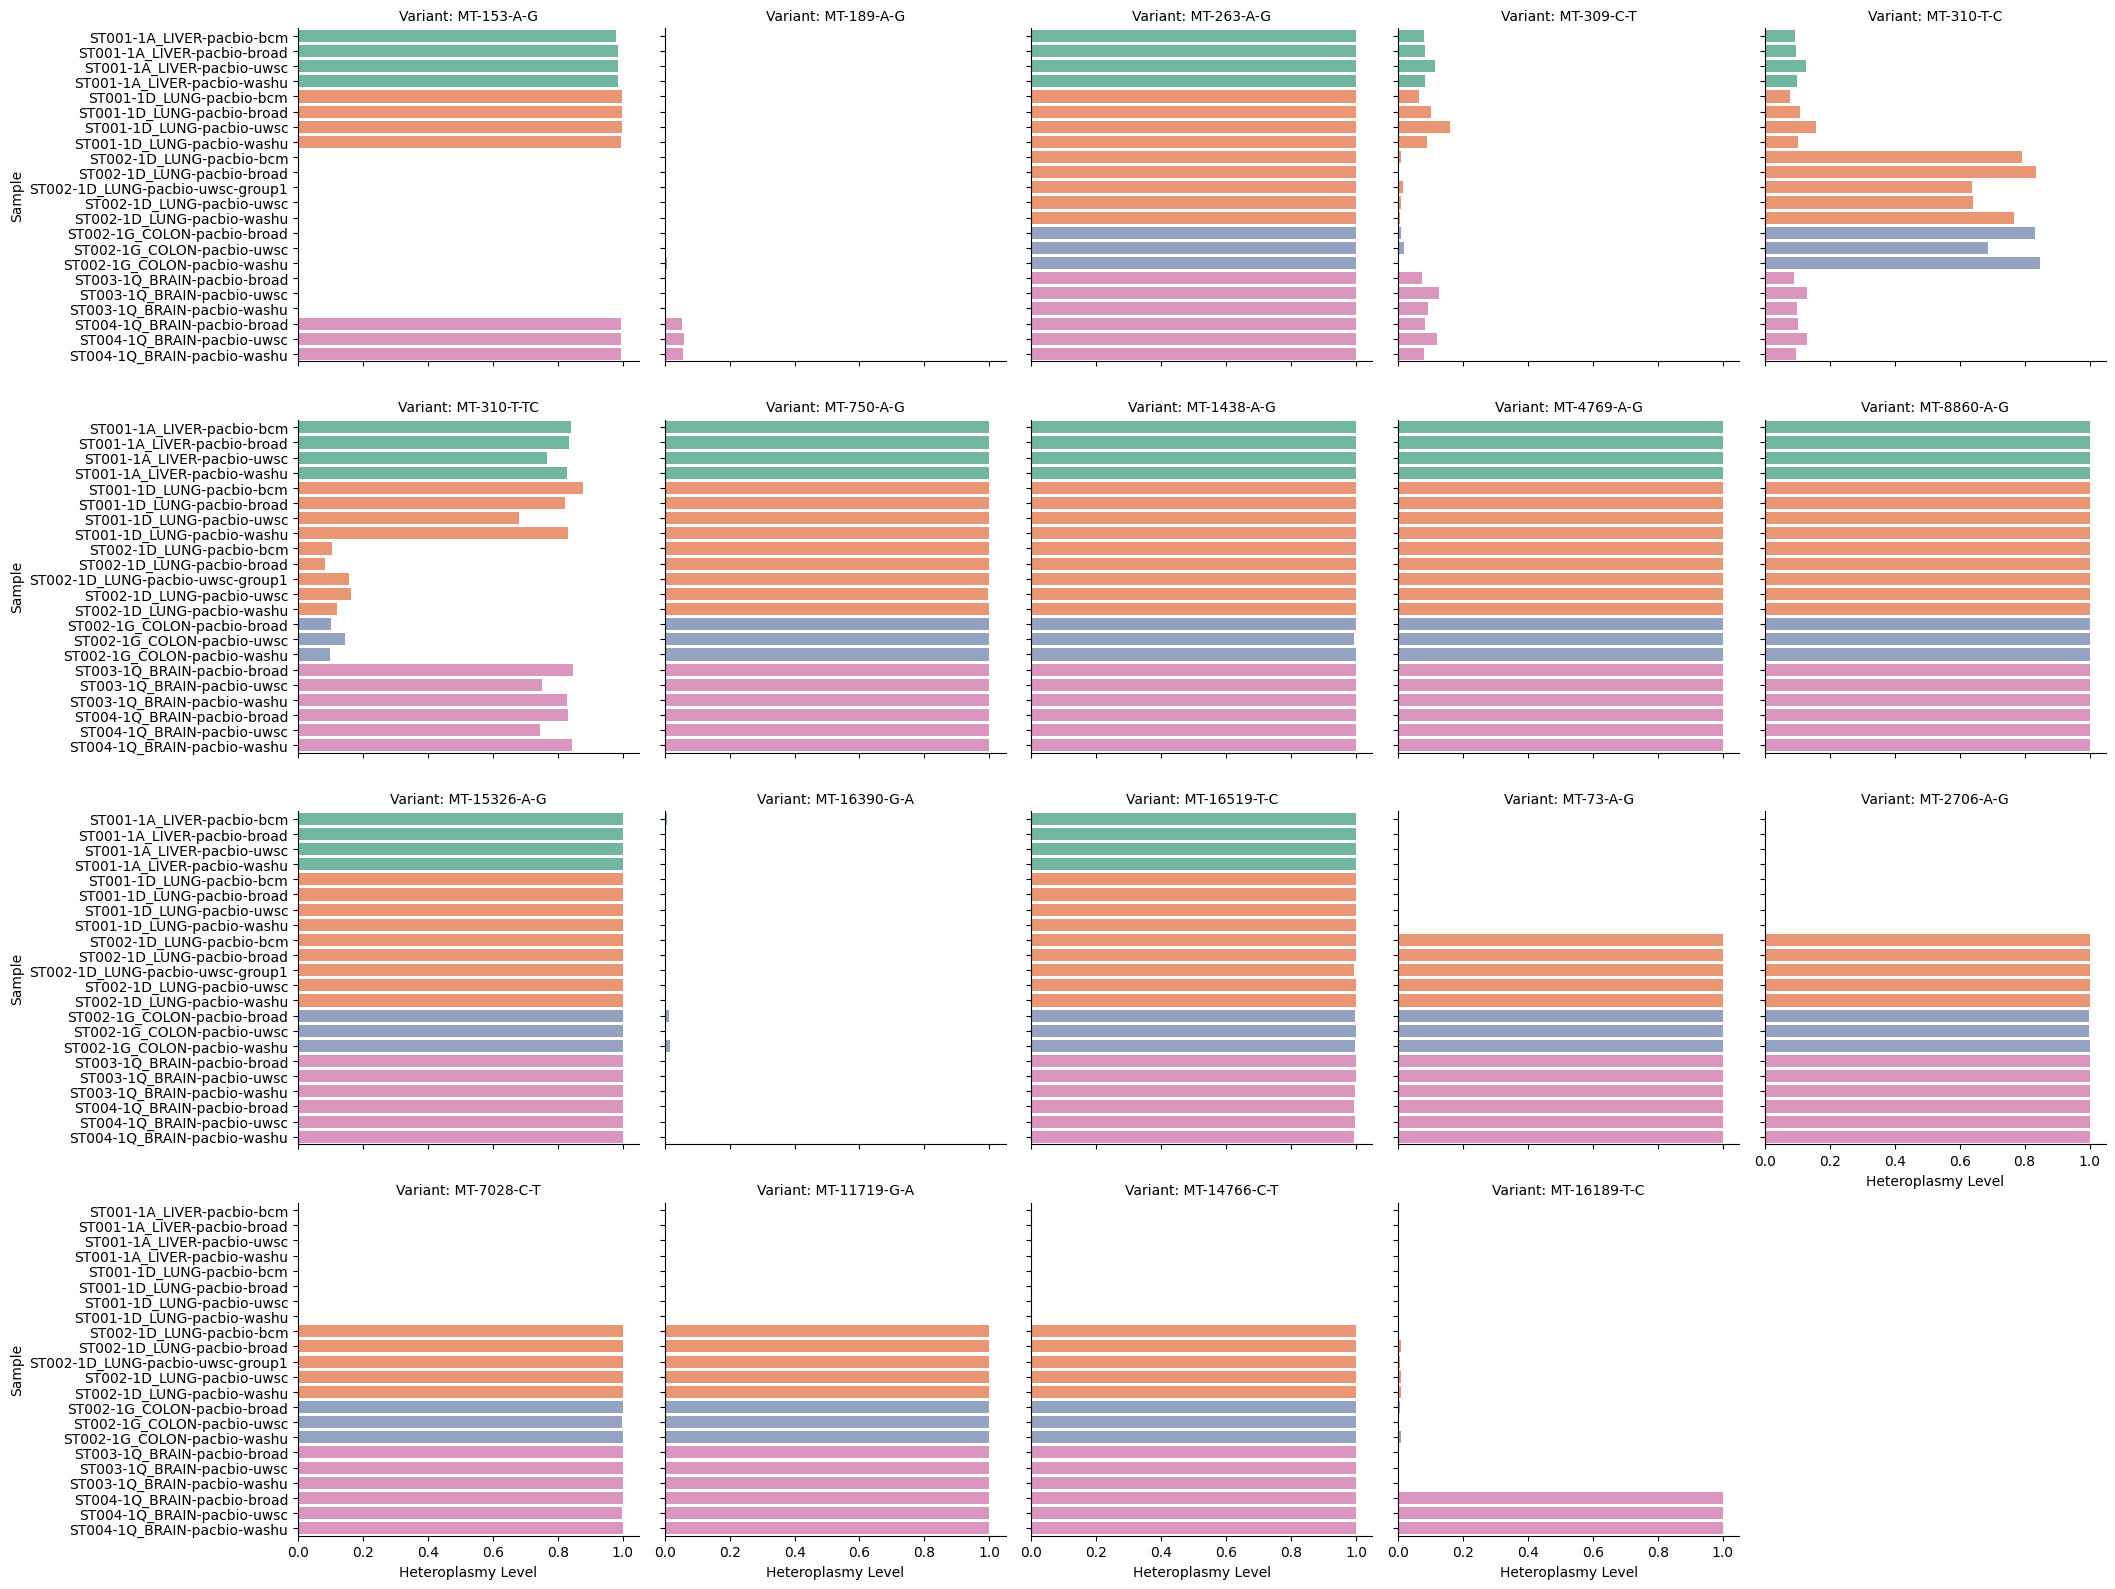

In [16]:
# Assuming df has columns: 'variant', 'sample', 'genotype' (heteroplasmy level)
variants = common_variants_df['ID'].unique()
all_samples = snv_df['Sample'].unique()

g = sns.catplot(
    data=common_variants_df,
    kind='bar',              # or 'point' if you want connected means
    x='AF',                    # Heteroplasmy level
    y='Sample',                # Sample names
    hue='Tissue',              # Color by tissue type
    col='ID',                  # One plot per variant
    col_wrap=5,
    height=4,
    sharex=True,
    palette=sns.color_palette("Set2", 10),            # Or another palette you like
)


g.set_titles(col_template='Variant: {col_name}')
g.set_xlabels('Heteroplasmy Level')
g.set_ylabels('Sample')

g._legend.remove()

# # Set x-axis limits for all plots to 0–1
# for ax in g.axes.flatten():
#     ax.set_xlim(0, 1)

plt.tight_layout()
plt.show()


/tmp/ipykernel_3660425/2541284465.py:5: UserWarning: The palette list has more values (8) than needed (4), which may not be intended.
  g = sns.catplot(


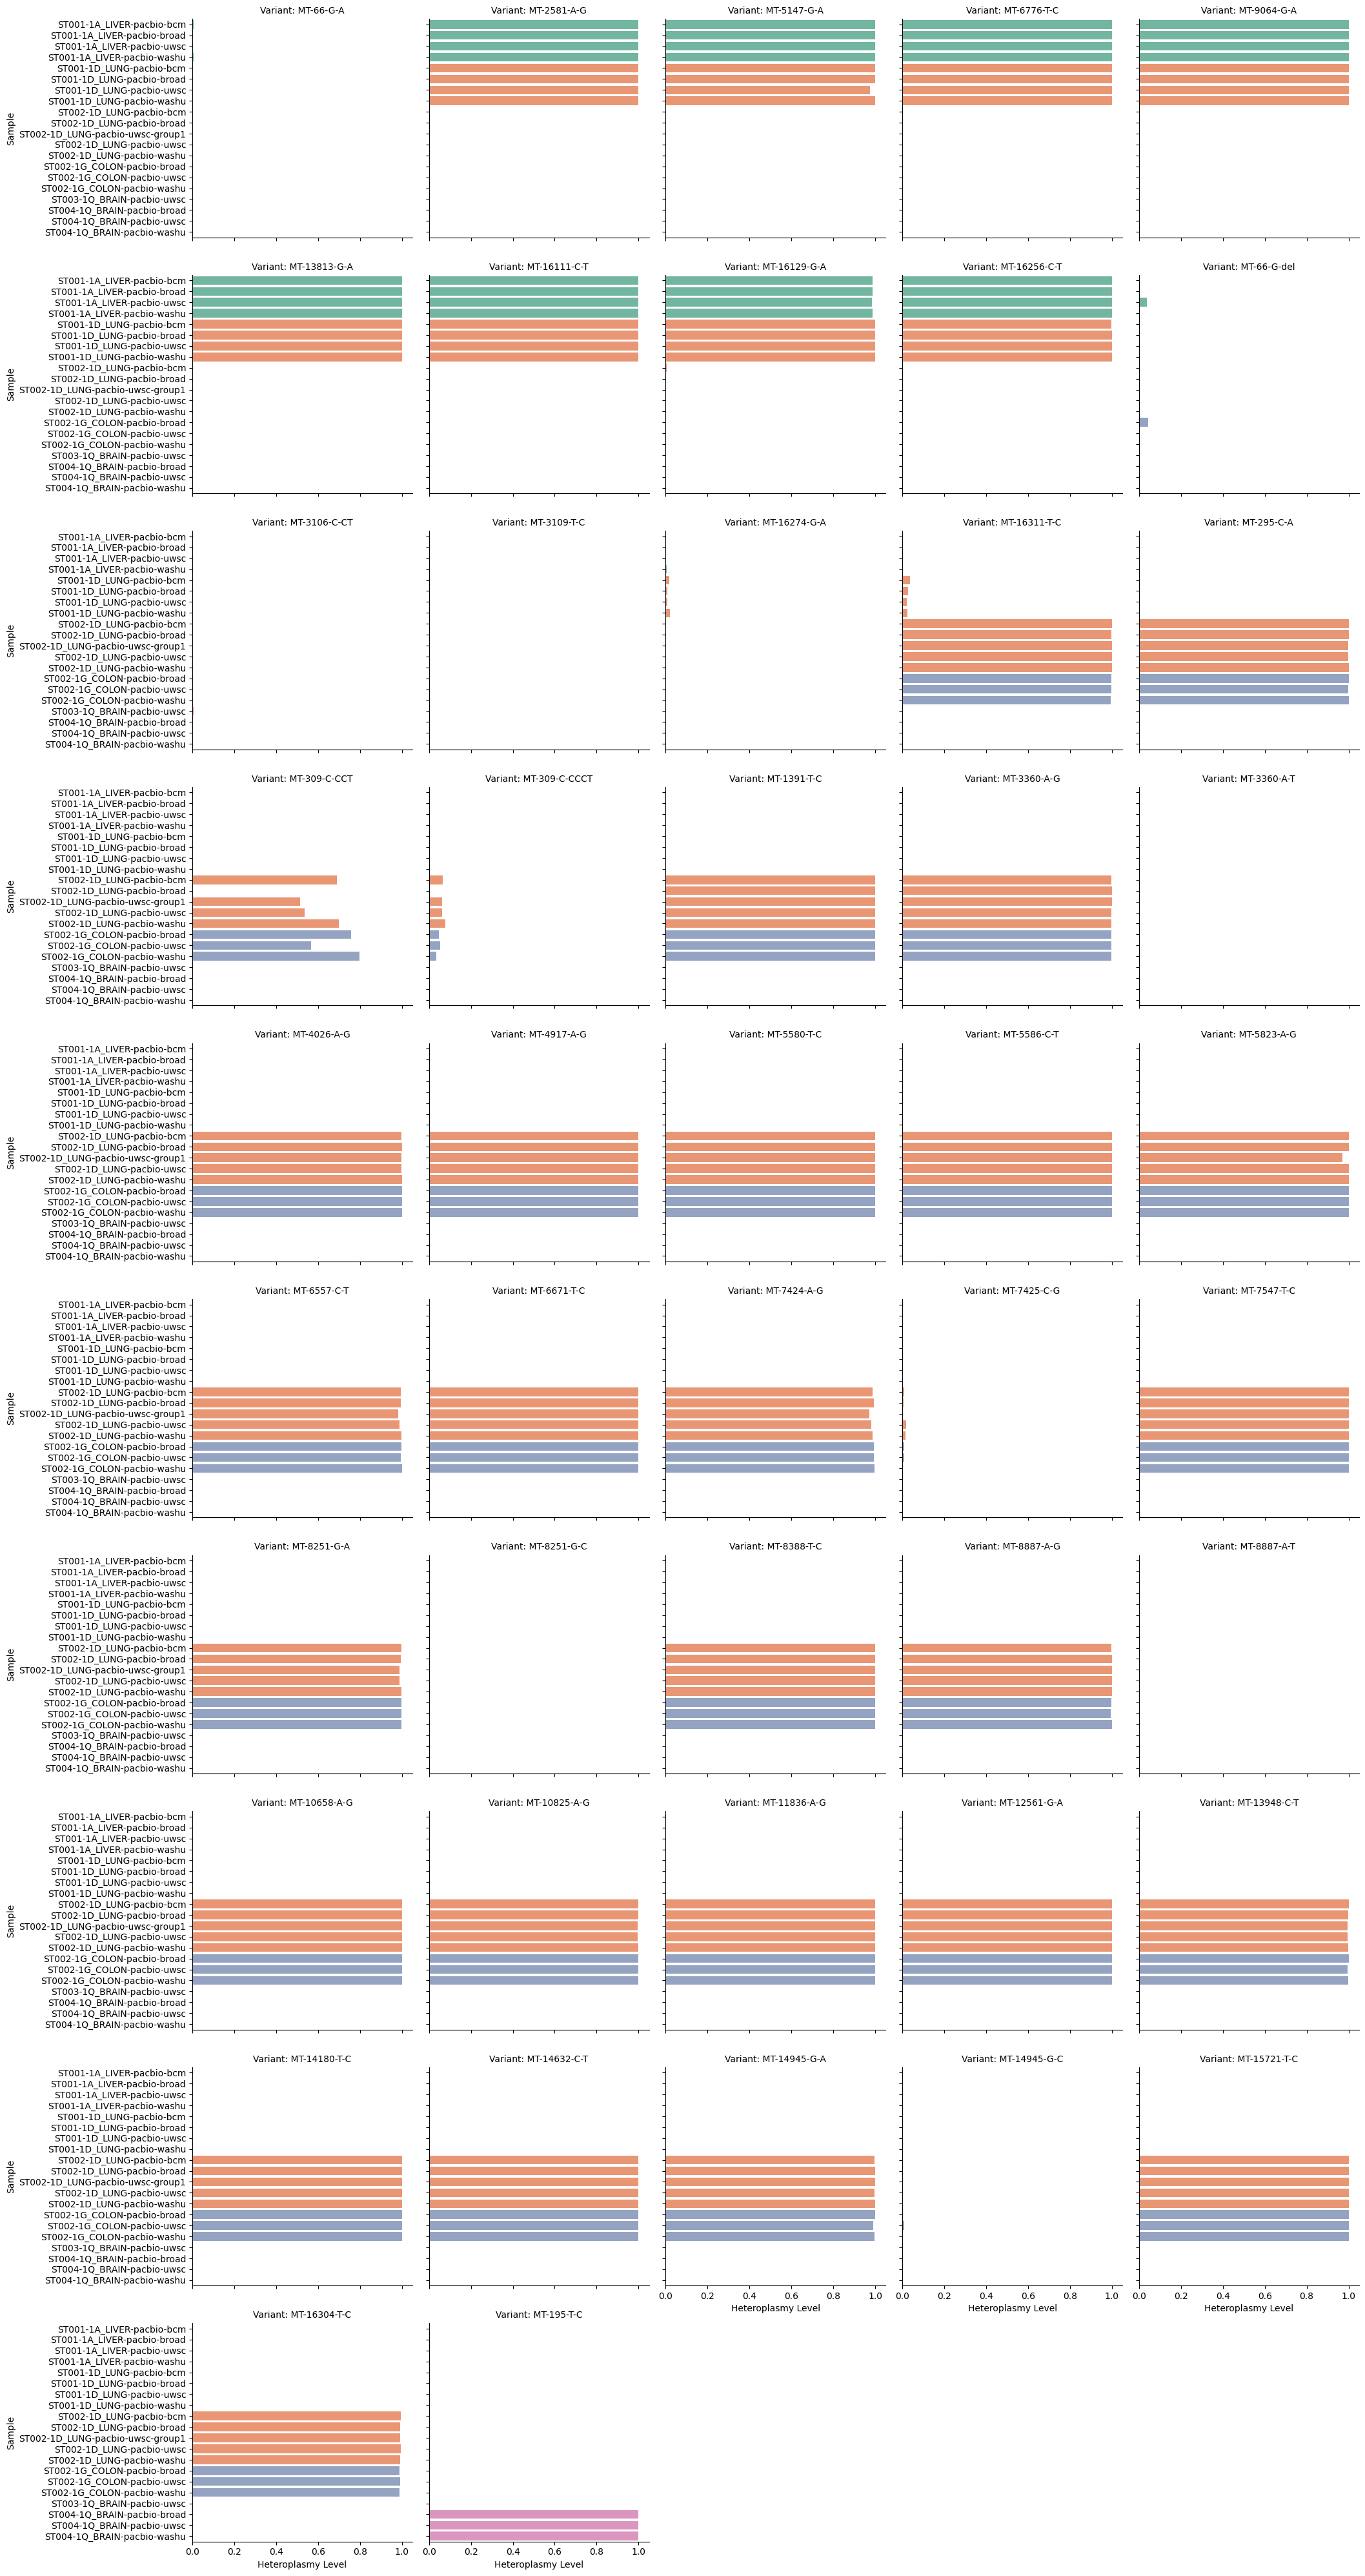

In [17]:
# Assuming df has columns: 'variant', 'sample', 'genotype' (heteroplasmy level)
variants = other_variants_df['ID'].unique()
all_samples = snv_df['Sample'].unique()

g = sns.catplot(
    data=other_variants_df,
    kind='bar',              # or 'point' if you want connected means
    x='AF',                    # Heteroplasmy level
    y='Sample',                # Sample names
    hue='Tissue',              # Color by tissue type
    col='ID',                  # One plot per variant
    col_wrap=5,
    height=4,
    sharex=True,
    palette=sns.color_palette("Set2"),            # Or another palette you like
)


g.set_titles(col_template='Variant: {col_name}')
g.set_xlabels('Heteroplasmy Level')
g.set_ylabels('Sample')

g._legend.remove()

# # Set x-axis limits for all plots to 0–1
# for ax in g.axes.flatten():
#     ax.set_xlim(0, 1)

plt.tight_layout()
plt.show()


/tmp/ipykernel_3660425/1738490061.py:5: UserWarning: The palette list has more values (8) than needed (4), which may not be intended.
  g = sns.catplot(


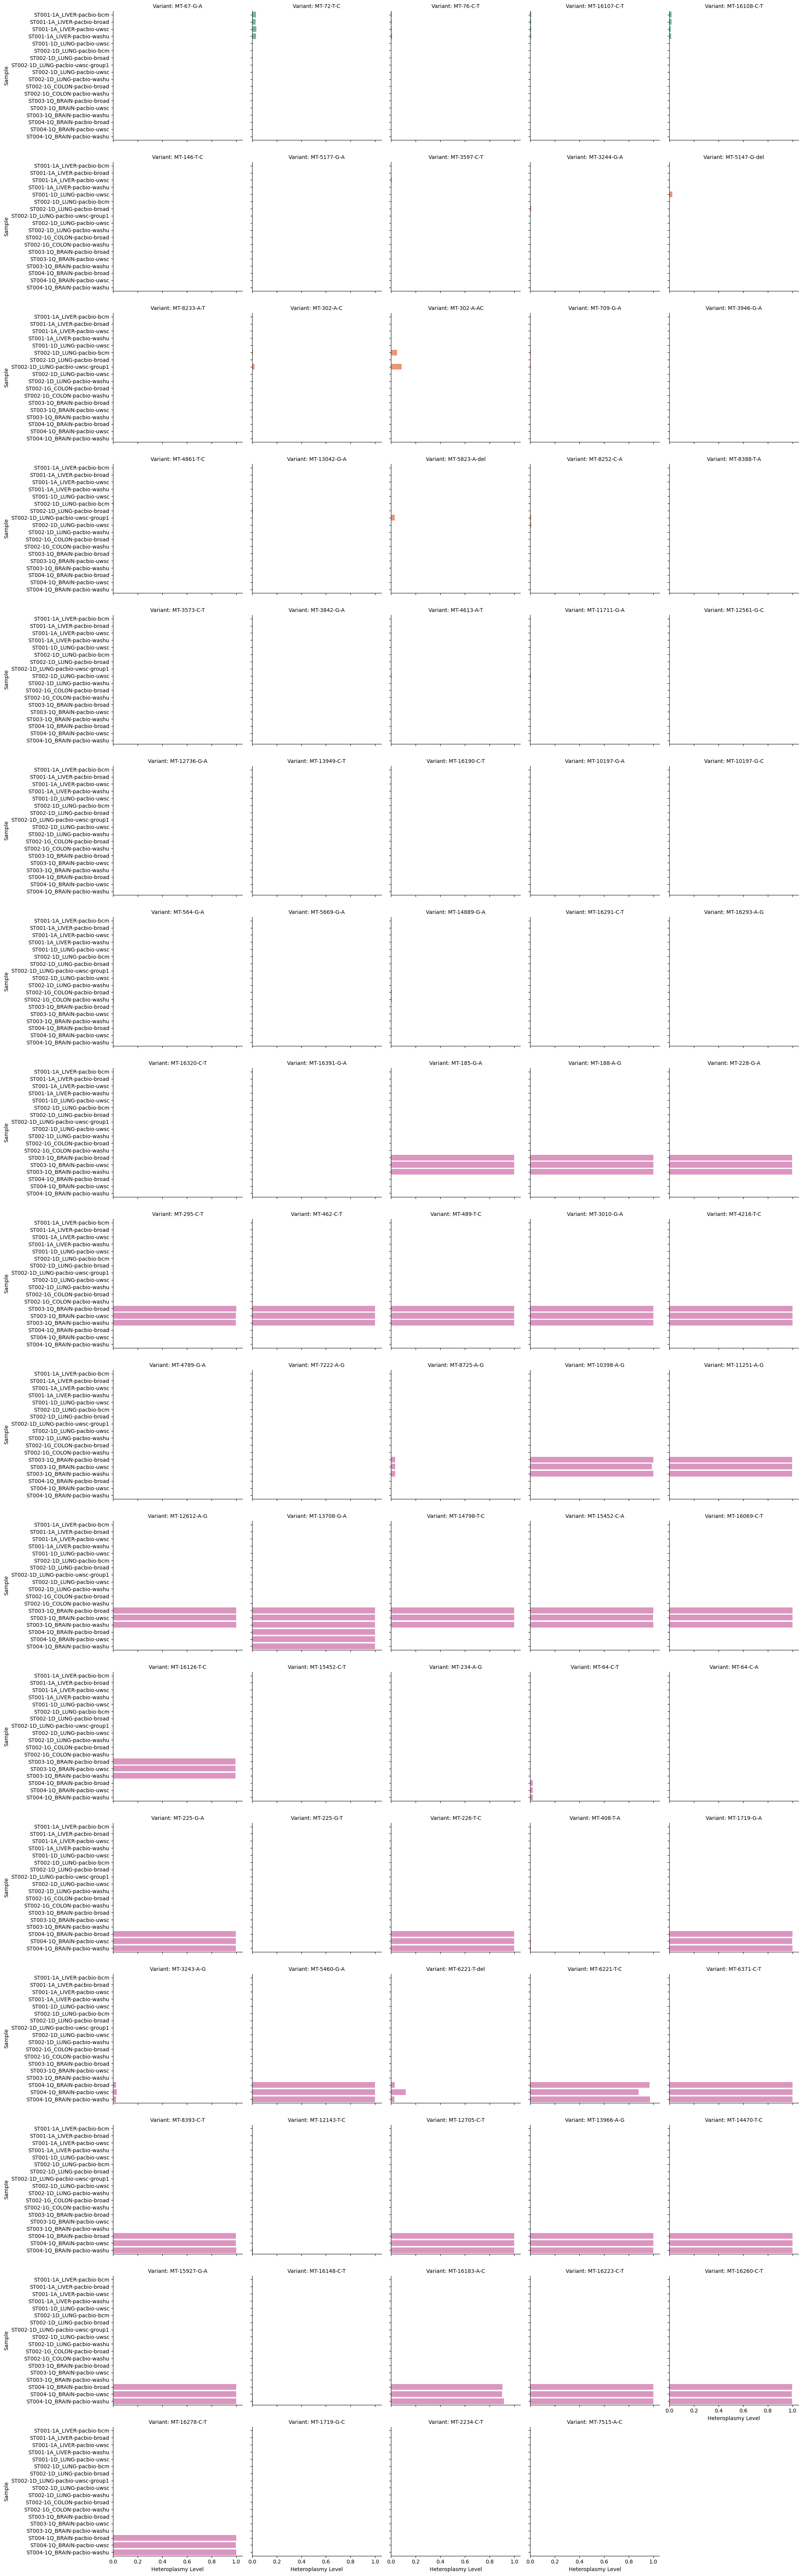

In [18]:
# Assuming df has columns: 'variant', 'sample', 'genotype' (heteroplasmy level)
variants = singleton_df['ID'].unique()
all_samples = snv_df['Sample'].unique()

g = sns.catplot(
    data=singleton_df,
    kind='bar',              # or 'point' if you want connected means
    x='AF',                    # Heteroplasmy level
    y='Sample',                # Sample names
    hue='Tissue',              # Color by tissue type
    col='ID',                  # One plot per variant
    col_wrap=5,
    height=4,
    sharex=True,
    palette=sns.color_palette("Set2"),            # Or another palette you like
)


g.set_titles(col_template='Variant: {col_name}')
g.set_xlabels('Heteroplasmy Level')
g.set_ylabels('Sample')

g._legend.remove()

# # Set x-axis limits for all plots to 0–1
# for ax in g.axes.flatten():
#     ax.set_xlim(0, 1)

plt.tight_layout()
plt.show()

In [1]:

heatmap_data = snv_df[snv_df['Donor'] == 'ST003'].pivot(index=['Sample','Donor'], columns='ID', values='AF')
#heatmap_data = snv_df.pivot(index=['Sample','Donor'], columns='ID', values='AF')


# Sort columns by highest average AF
column_order = heatmap_data.mean(axis=0).sort_values(ascending=False).index
heatmap_data = heatmap_data[column_order]

# Plot heatmap
plt.figure(figsize=(16, 6))
sns.heatmap(heatmap_data, cmap="viridis", annot=False, cbar_kws={'label': 'Heteroplasmy Level'})
plt.title('Heteroplasmy Heatmap')
plt.xlabel('Variant')
plt.ylabel('Sample')
plt.tight_layout()
plt.show()



NameError: name 'snv_df' is not defined